# HBV hydrological model forced with DestinE SSP370 forcing data
In this notebook we will generate forcing data for the HBV hydrological model from the output of project DestinE, simulating the SSP370 CMIP6 scenario climate model using the eWaterCycle platform. eWaterCycles integration of DestinE data is still quite new 

The code in this notebook is nearly identical to the code in [this notebook](step_1a_generate_historical_forcing.ipynb) where we generated both ERA5 and historical CMIP6 forcing data. For detailed descriptions, see that notebook.

In [3]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import json
from esmvalcore.config import CFG
import time
import sys

# Niceties
from rich import print

# destinE
# from forcing_destine import DestinEForcing
# from dest_auth import authenticate as dest_auth

# This will work normally for HPC
try:
    from scripts.forcing_destine import DestinEForcing
    from scripts.dest_auth import authenticate as dest_auth
except ImportError:
    # Add the project root to Python path for use on SRC
    project_root = Path().resolve().parent
    sys.path.append(str(project_root))
    
    from scripts.forcing_destine import DestinEForcing
    from scripts.dest_auth import authenticate as dest_auth

dest_auth()

Authenticating on https://auth.destine.eu with user mmelotto


In [2]:
# General eWaterCycle
import ewatercycle
import ewatercycle.forcing

In [ ]:
# Parameters, these get changed when running on HPC
country = "australia"
region_id = "camelsaus_102101A"
settings_path = "settings.json"

In [3]:
# Load settings
# Read from the JSON file
with open(settings_path, "r") as json_file:
    settings = json.load(json_file)

In [4]:
display(settings)

{
    'caravan_id': 'hysets_02472000',
    'calibration_start_date': '1994-08-01T00:00:00Z',
    'calibration_end_date': '2004-07-31T00:00:00Z',
    'validation_start_date': '2004-08-01T00:00:00Z',
    'validation_end_date': '2014-07-31T00:00:00Z',
    'future_start_date': '2029-08-01T00:00:00Z',
    'future_end_date': '2049-08-31T00:00:00Z',
    'CMIP_info': {
        'dataset': ['MPI-ESM1-2-HR'],
        'ensembles': ['r1i1p1f1', 'r2i1p1f1'],
        'experiments': ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585'],
        'project': 'CMIP6',
        'frequency': 'day',
        'grid': 'gn',
        'variables': ['pr', 'tas', 'rsds']
    },
    'base_path': '/home/rhut/ewatercycleClimateImpact/HBV',
    'path_caravan': '/home/rhut/ewatercycleClimateImpact/HBV/forcing_data/hysets_02472000/caravan',
    'path_ERA5': '/home/rhut/ewatercycleClimateImpact/HBV/forcing_data/hysets_02472000/ERA5',
    'path_CMIP6': '/home/rhut/ewatercycleClimateImpact/HBV/forcing_data/hysets_02472000/CMIP6',
    'path_output': '/home/rhut/ewatercycleClimateImpact/HBV/output_data/hysets_02472000',
    'path_shape': 
'/home/rhut/ewatercycleClimateImpact/HBV/forcing_data/hysets_02472000/caravan/hysets_02472000.shp'
}

## DestinE SSP370 future forcing

The DestinE Digital Twin for Climate Change Adaptation (Climate DT) supports adaptation activities by providing innovative climate information on multi-decadal timescales, globally, at scales at which many impacts of climate change are observed. It combines cutting-edge global Earth-system models, impact-sector applications and observations into a unified framework to provide global climate projections and impact-sector information on multi-decadal timescales (1990 to ~2050), at very high spatial resolutions (5 to 10 km). The data from the first prototype projections is already available through the DestinE platform for users with upgraded access. 

eWaterCycle is in partnership with project DestinE, and this is placeholder function. We are working with ESMValTool to facilitate working with the zarr data that DestinE provides.

MPI-ESM1-2-HR

ssp126

r1i1p1f1

LumpedMakkinkForcing(
    start_time='2029-08-01T00:00:00Z',
    end_time='2049-08-31T00:00:00Z',
    directory=PosixPath('/home/rhut/ewatercycleClimateImpact/HBV/forcing_data/hysets_02472000/CMIP6/MPI-ESM1-2-HR/s
sp126/r1i1p1f1/work/diagnostic/script'),
    shape=PosixPath('/home/rhut/ewatercycleClimateImpact/HBV/forcing_data/hysets_02472000/caravan/hysets_02472000.s
hp'),
    filenames={
        'pr': 'CMIP6_MPI-ESM1-2-HR_day_ssp126_r1i1p1f1_pr_gn_2029-2049.nc',
        'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp126_r1i1p1f1_tas_gn_2029-2049.nc',
        'rsds': 'CMIP6_MPI-ESM1-2-HR_day_ssp126_r1i1p1f1_rsds_gn_2029-2049.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

r2i1p1f1

...

r1i1p1f1

LumpedMakkinkForcing(
    start_time='2029-08-01T00:00:00Z',
    end_time='2049-08-31T00:00:00Z',
    directory=PosixPath('/home/rhut/ewatercycleClimateImpact/HBV/forcing_data/hysets_02472000/CMIP6/MPI-ESM1-2-HR/s
sp585/r1i1p1f1/work/diagnostic/script'),
    shape=PosixPath('/home/rhut/ewatercycleClimateImpact/HBV/forcing_data/hysets_02472000/caravan/hysets_02472000.s
hp'),
    filenames={
        'pr': 'CMIP6_MPI-ESM1-2-HR_day_ssp585_r1i1p1f1_pr_gn_2029-2049.nc',
        'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp585_r1i1p1f1_tas_gn_2029-2049.nc',
        'rsds': 'CMIP6_MPI-ESM1-2-HR_day_ssp585_r1i1p1f1_rsds_gn_2029-2049.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

r2i1p1f1

ERROR:esmvalcore.esgf._download:Failed to download ESGFFile:CMIP6/ScenarioMIP/DWD/MPI-ESM1-2-HR/ssp585/r2i1p1f1/day/rsds/gn/v20190710/rsds_day_MPI-ESM1-2-HR_ssp585_r2i1p1f1_gn_20250101-20291231.nc on hosts ['esgf.dwd.de'], error message Failed to download file /home/rhut/.esmvaltool/downloads/CMIP6/ScenarioMIP/DWD/MPI-ESM1-2-HR/ssp585/r2i1p1f1/day/rsds/gn/v20190710/rsds_day_MPI-ESM1-2-HR_ssp585_r2i1p1f1_gn_20250101-20291231.nc, errors:
https://esgf.dwd.de/thredds/fileServer/esgf2_1/CMIP6/ScenarioMIP/DWD/MPI-ESM1-2-HR/ssp585/r2i1p1f1/day/rsds/gn/v20190710/rsds_day_MPI-ESM1-2-HR_ssp585_r2i1p1f1_gn_20250101-20291231.nc: HTTPSConnectionPool(host='esgf.dwd.de', port=443): Max retries exceeded with url: /thredds/fileServer/esgf2_1/CMIP6/ScenarioMIP/DWD/MPI-ESM1-2-HR/ssp585/r2i1p1f1/day/rsds/gn/v20190710/rsds_day_MPI-ESM1-2-HR_ssp585_r2i1p1f1_gn_20250101-20291231.nc (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has exp

DownloadError: Failed to download the following files:
Failed to download file /home/rhut/.esmvaltool/downloads/CMIP6/ScenarioMIP/DWD/MPI-ESM1-2-HR/ssp585/r2i1p1f1/day/rsds/gn/v20190710/rsds_day_MPI-ESM1-2-HR_ssp585_r2i1p1f1_gn_20250101-20291231.nc, errors:
https://esgf.dwd.de/thredds/fileServer/esgf2_1/CMIP6/ScenarioMIP/DWD/MPI-ESM1-2-HR/ssp585/r2i1p1f1/day/rsds/gn/v20190710/rsds_day_MPI-ESM1-2-HR_ssp585_r2i1p1f1_gn_20250101-20291231.nc: HTTPSConnectionPool(host='esgf.dwd.de', port=443): Max retries exceeded with url: /thredds/fileServer/esgf2_1/CMIP6/ScenarioMIP/DWD/MPI-ESM1-2-HR/ssp585/r2i1p1f1/day/rsds/gn/v20190710/rsds_day_MPI-ESM1-2-HR_ssp585_r2i1p1f1_gn_20250101-20291231.nc (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1000)')))
Failed to download file /home/rhut/.esmvaltool/downloads/CMIP6/ScenarioMIP/DWD/MPI-ESM1-2-HR/ssp585/r2i1p1f1/day/rsds/gn/v20190710/rsds_day_MPI-ESM1-2-HR_ssp58

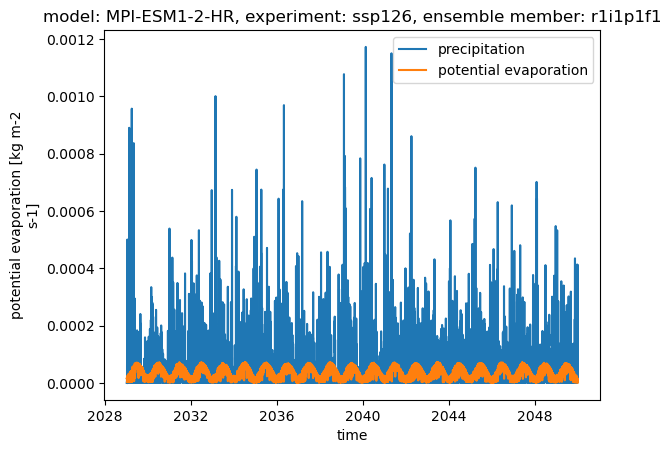

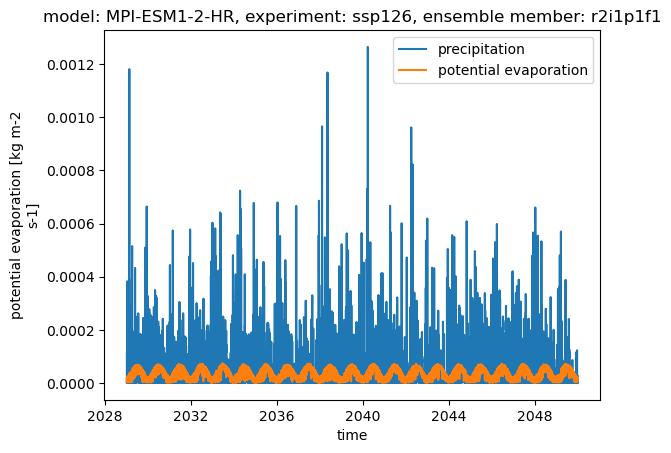

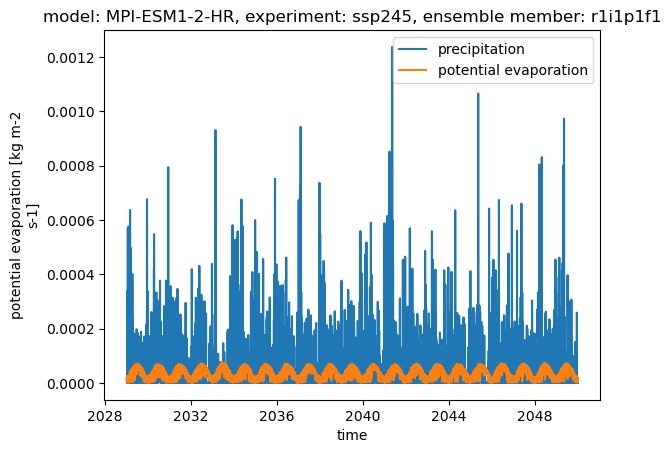

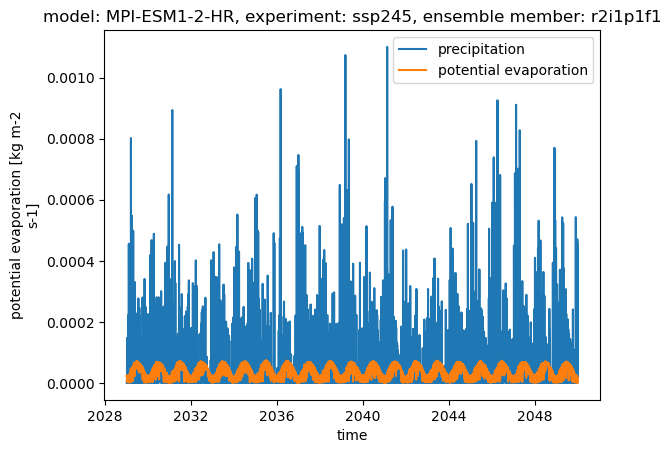

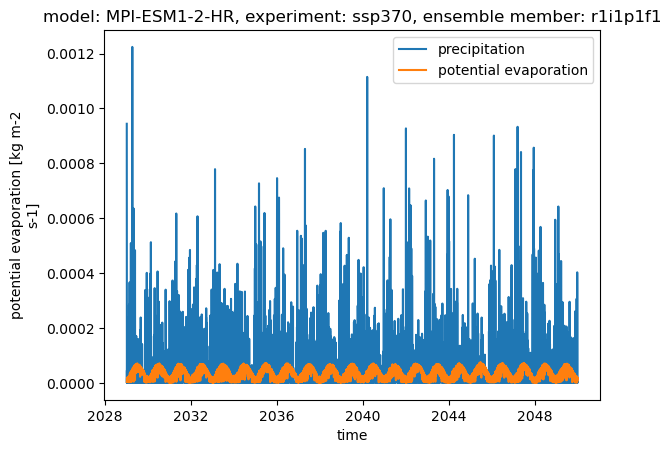

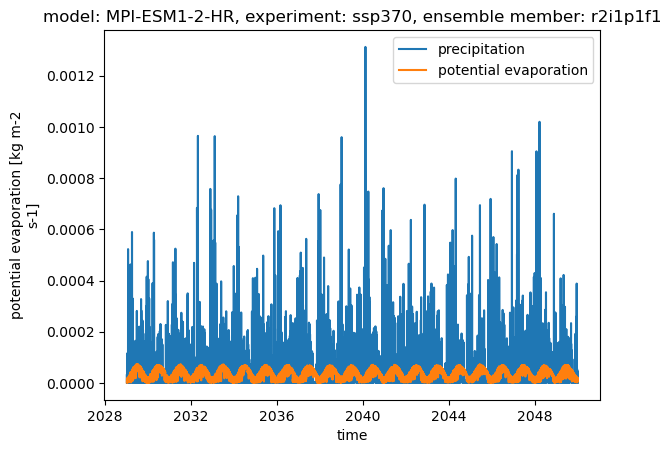

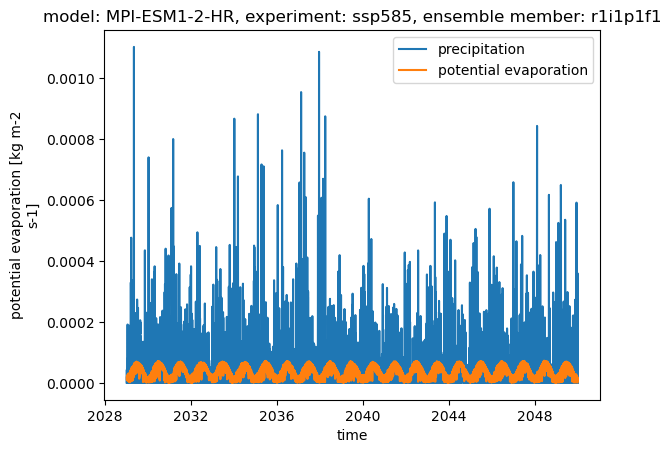

In [5]:
# Generate forcing:
try:
    DestinE_forcing_object = DestinEForcing.load(settings['path_DestinE'])
except:
    DestinE_forcing_object = DestinEForcing.generate(
       start_time=settings['future_start_date'],
       end_time=settings['future_end_date'],
       directory=settings['path_DestinE'],
       shape=settings['path_shape'],
    )

display(DestinE_forcing_object)

# Quick plot of the precipitation and potential evaporation data
plt.figure()
ds_DestinE = xr.open_mfdataset([DestinE_forcing_object['pr'],DestinE_forcing_object['evspsblpot']])
ds_DestinE["pr"].plot(label = 'precipitation')
ds_DestinE["evspsblpot"].plot(label = 'potential evaporation')
plt.legend()
plt.title('model: DestinE SSP370') 